# Land Cover Mapping (Advanced)

This tutorial extends the [basic land cover mapping](03_landcover_mapping.ipynb)
workflow with four advanced topics, still using only the bundled toy data:

1. **Probability output** — predict class probabilities instead of hard labels.
2. **Feature importance / selection** — inspect and prune the covariates.
3. **Ensemble learning** — combine several estimators with a `VotingClassifier`.
4. **Saving / loading** — persist the model and reload it with
   :class:`~skmap.io.process.Prediction`.


## Setup

We reuse the exact same dataset, catalog and space-time overlay from the basic
tutorial to build the training table.

In [1]:
import os

os.environ["PROJ_LIB"] = "/skmap/lib/python3.12/site-packages/rasterio/proj_data"
os.environ["PROJ_DATA"] = "/skmap/lib/python3.12/site-packages/rasterio/proj_data"

In [2]:
import warnings

warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

from skmap.io import RasterData
from skmap.data import toy
from skmap.overlay import SpaceTimeOverlay

samples = toy.lc_samples()
backend='cpp' 

# Load the catalogue from layers.yaml and restrict to the full years 2015-2019.
rdata = (
    RasterData.from_yaml(str(toy.LAYERS_YAML),  backend=backend, base_path=str(toy.DATA_DIR))
    .filter("variant != 'gappy'")
    .filter_date("2015-01-01", "2019-12-31", include_non_temporal=True, by_start_date=True)
)

overlay = SpaceTimeOverlay(
    points=samples,
    col_date="date",
    rasterdata=rdata,
    date_ranges=[(f"{y}-01-01", f"{y}-12-31") for y in range(2015, 2020)],
    raster_tiles=None,
    verbose=False,
)
train = overlay.run(max_ram_mb=512, out_file_name=None)

# Year-agnostic seasonal feature names (set by the layers.yaml ``name`` template).
features = [
    "ndvi_winter", "ndvi_spring", "ndvi_summer", "ndvi_fall",
    "swir1_winter", "swir1_spring", "swir1_summer", "swir1_fall",
    "elev", "slope",
]
X = train[features]
X.shape


Dropping 0 points out of 41 because out of extent
Dropping 0 points out of 37 because out of extent
Dropping 0 points out of 40 because out of extent
Dropping 0 points out of 43 because out of extent
Dropping 0 points out of 38 because out of extent


(199, 10)

In [3]:
from sklearn.preprocessing import LabelEncoder

target_col = 'label'

le = LabelEncoder()
y = le.fit_transform(train[target_col].values)

## Probability output

A probabilistic classifier returns, for each pixel, a probability distribution
over the classes. We train a random forest and evaluate it with the
[log loss](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.log_loss.html).

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss
from sklearn.model_selection import cross_val_predict

clf = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)

# Out-of-fold probabilities (one row per sample, one column per class)
probs = cross_val_predict(clf, X, y, method="predict_proba", cv=5)
print(f"Out-of-fold log loss: {log_loss(y, probs):.3f}")


Out-of-fold log loss: 1.296


In [5]:
clf.fit(X, y)
probs = clf.predict_proba(X)
print("Probability matrix shape:", probs.shape)
print("Classes:", clf.classes_)


Probability matrix shape: (199, 14)
Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]


## Feature importance / selection

Random forests expose per-feature importances. We can use them to understand the
model and to drop the least useful covariate.

In [6]:
import pandas as pd

importance = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False)
importance


swir1_summer    0.146663
ndvi_spring     0.123759
elev            0.112399
swir1_fall      0.109247
ndvi_summer     0.101852
swir1_spring    0.101066
ndvi_fall       0.090426
ndvi_winter     0.080590
swir1_winter    0.075272
slope           0.058725
dtype: float64

In [7]:
from sklearn.feature_selection import SelectFromModel

# Keep only features with importance above the median
selector = SelectFromModel(clf, threshold="median", prefit=True)
X_sel = selector.transform(X)
print("Selected features:", [features[i] for i in selector.get_support(indices=True)])
print("Reduced shape:", X_sel.shape)


Selected features: ['ndvi_spring', 'ndvi_summer', 'swir1_summer', 'swir1_fall', 'elev']
Reduced shape: (199, 5)


## Ensemble learning

We combine a random forest, a logistic regression and a support vector machine
into a soft-voting ensemble.

In [8]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

voting = VotingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)),
        ("lr", LogisticRegression(max_iter=1000, random_state=0)),
        ("svc", SVC(probability=True, random_state=0)),
    ],
    voting="soft",
)

scores = cross_val_score(voting, X, y, cv=5)
print(f"Ensemble cross-validated accuracy: {scores.mean():.3f} +/- {scores.std():.3f}")


Ensemble cross-validated accuracy: 0.694 +/- 0.035


In [9]:
voting.fit(X, y)
print(f"Ensemble training accuracy: {voting.score(X, y):.3f}")


Ensemble training accuracy: 0.960


## Saving / loading the model

The fitted model can be persisted with `joblib` and reloaded with
`joblib.load`.  Spatial prediction is done through
:class:`~skmap.io.process.Prediction`.


In [10]:
import joblib

model_path = "landcover_rf.joblib"
joblib.dump(clf, model_path)

model = joblib.load(model_path)
print("Feature names:", list(model.feature_names_in_))
print("Predictions:", model.predict(X.values[:5]))


Feature names: ['ndvi_winter', 'ndvi_spring', 'ndvi_summer', 'ndvi_fall', 'swir1_winter', 'swir1_spring', 'swir1_summer', 'swir1_fall', 'elev', 'slope']
Predictions: [ 9  9  0  0 12]


## Multi-year spatial prediction

:class:`~skmap.io.process.Prediction` predicts **all years in one
model call**: the years are concatenated into a single feature matrix with
the static covariates repeated for each year.  For a probability classifier
it appends one probability band per ``(class, year)`` *and* a dominant-class
band (argmax) per year, all under the ``prediction`` group.  ``drop_input``
removes the consumed covariates so only the predictions remain.


In [11]:
from skmap.io import RasterData
from skmap.io.process import Prediction

rdata = (
    RasterData.from_yaml(str(toy.LAYERS_YAML), base_path=str(toy.DATA_DIR), backend=backend)
    .filter("variant != 'gappy'")
    .filter_date("2015-01-01", "2019-12-31", include_non_temporal=True, by_start_date=True)
    .read()
)

# predict_proba -> per-class probabilities + a dominant-class band (argmax).
# drop_input keeps only the prediction bands.
rdata.run(Prediction(model=model, predict_proba=True, valid_only=False,
                     target_names=le.classes_.astype(str).tolist()),
          drop_input=True)
rdata.info
#years = rdata.get_years()
#n_years = len(years)
#n_class = len(le.classes_)
#arr = rdata.array.get()
#proba = arr[: n_class * n_years].reshape(n_class, n_years, -1)
#dominant = arr[n_class * n_years :].reshape(n_years, -1)
#proba.shape, dominant.shape


,group,input_path,input_band,start_date,end_date,temporal,name,band,variant,season,year
0,prediction,/root/scikit-map/skmap/data/toy/ndvi/filled/nd...,1,2015-01-01,2015-12-31,True,prediction_Broad-leaved forest,NaN,NaN,NaN,2015.0
1,prediction,/root/scikit-map/skmap/data/toy/ndvi/filled/nd...,1,2016-01-01,2016-12-31,True,prediction_Broad-leaved forest,NaN,NaN,NaN,2016.0
2,prediction,/root/scikit-map/skmap/data/toy/ndvi/filled/nd...,1,2017-01-01,2017-12-31,True,prediction_Broad-leaved forest,NaN,NaN,NaN,2017.0
3,prediction,/root/scikit-map/skmap/data/toy/ndvi/filled/nd...,1,2018-01-01,2018-12-31,True,prediction_Broad-leaved forest,NaN,NaN,NaN,2018.0
4,prediction,/root/scikit-map/skmap/data/toy/ndvi/filled/nd...,1,2019-01-01,2019-12-31,True,prediction_Broad-leaved forest,NaN,NaN,NaN,2019.0
...,...,...,...,...,...,...,...,...,...,...,...
70,prediction,/root/scikit-map/skmap/data/toy/ndvi/filled/nd...,1,2015-01-01,2015-12-31,True,prediction,NaN,NaN,NaN,2015.0
71,prediction,/root/scikit-map/skmap/data/toy/ndvi/filled/nd...,1,2016-01-01,2016-12-31,True,prediction,NaN,NaN,NaN,2016.0
72,prediction,/root/scikit-map/skmap/data/toy/ndvi/filled/nd...,1,2017-01-01,2017-12-31,True,prediction,NaN,NaN,NaN,2017.0
73,prediction,/root/scikit-map/skmap/data/toy/ndvi/filled/nd...,1,2018-01-01,2018-12-31,True,prediction,NaN,NaN,NaN,2018.0


In [12]:
rdata.info['group'].value_counts()

group
prediction    75
Name: count, dtype: int64

In [13]:
from matplotlib.colors import ListedColormap

legend = {
	'Broad-leaved forest': '#80FF00',
	'Coniferous forest': '#00A600',
	'Continuous urban fabric': '#558b2f',
	'Discontinuous urban fabric': '#FF0000',
	'Green urban areas': '#FFA6FF',
	'Industrial or commercial units': '#CC4DF2',
	'Land principally occupied by agriculture, with significant areas of natural vegetation': '#E6CC4D',
	'Mixed forest': '#4DFF00',
	'Non-irrigated arable land': '#FFFFA8',
	'Pastures': '#E6E64D',
	'Road and rail networks and associated land': '#CC0000',
	'Sport and leisure facilities': '#FFE6FF',
	'Water bodies': '#80F2E6',
	'Water courses': '#00CCF2'
}

lc_classes = le.classes_
pixel_values = le.transform(lc_classes)
colors = ListedColormap([ legend[c] for c in le.classes_ ])

print("Mapped land cover classes")
for l, p, c in zip(lc_classes, pixel_values, colors.colors):
    print(f' - {l} => pixel value {p} ({c})')

Mapped land cover classes
 - Broad-leaved forest => pixel value 0 (#80FF00)
 - Coniferous forest => pixel value 1 (#00A600)
 - Continuous urban fabric => pixel value 2 (#558b2f)
 - Discontinuous urban fabric => pixel value 3 (#FF0000)
 - Green urban areas => pixel value 4 (#FFA6FF)
 - Industrial or commercial units => pixel value 5 (#CC4DF2)
 - Land principally occupied by agriculture, with significant areas of natural vegetation => pixel value 6 (#E6CC4D)
 - Mixed forest => pixel value 7 (#4DFF00)
 - Non-irrigated arable land => pixel value 8 (#FFFFA8)
 - Pastures => pixel value 9 (#E6E64D)
 - Road and rail networks and associated land => pixel value 10 (#CC0000)
 - Sport and leisure facilities => pixel value 11 (#FFE6FF)
 - Water bodies => pixel value 12 (#80F2E6)
 - Water courses => pixel value 13 (#00CCF2)


The dominant-class band and plot the dominant class map:

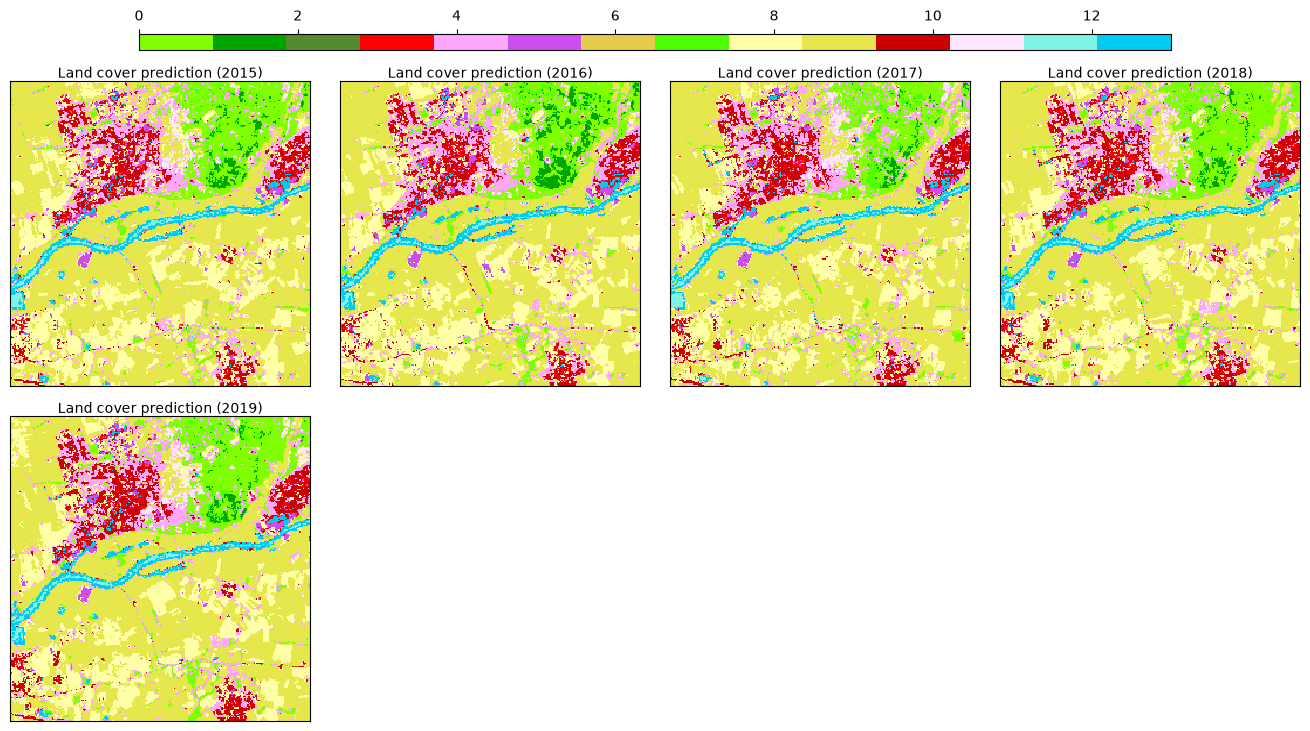

In [23]:
cls = 'Pastures'
rdata.filter(f"name == 'prediction'").plot(cmap=colors, img_title_text='Land cover {group} ({year})')